In [2]:
import pandas as pd
import polars as pl
from datetime import date
from rake_nltk import Rake
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Loading to db
# importing os module for environment variables
import os
# importing necessary functions from dotenv library
from dotenv import load_dotenv 
# loading variables from .env file
load_dotenv() 
import psycopg2
from sqlalchemy import create_engine 

# Raw Pubmed Data (no abstract or author)

In [3]:
pm_df = pd.read_csv("/Users/shantibrodnick/Downloads/510Capstone/GenderDisparityinResearch/data/raw/final_raw_pubmed_data.csv")

In [4]:
pm_df.info()
# 10,206,788 rows

<class 'pandas.DataFrame'>
RangeIndex: 10206788 entries, 0 to 10206787
Data columns (total 5 columns):
 #   Column      Dtype
---  ------      -----
 0   Unnamed: 0  int64
 1   title       str  
 2   journal     str  
 3   date        str  
 4   doi         str  
dtypes: int64(1), str(4)
memory usage: 2.0 GB


In [5]:
pm_df = pm_df.drop(['Unnamed: 0'], axis = 1)

In [6]:
pm_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10206788 entries, 0 to 10206787
Data columns (total 4 columns):
 #   Column   Dtype
---  ------   -----
 0   title    str  
 1   journal  str  
 2   date     str  
 3   doi      str  
dtypes: str(4)
memory usage: 2.0 GB


In [ ]:
print(pm_df['date'].astype(str).str.len().value_counts())


date
10    10201811
4         4977
Name: count, dtype: int64


In [11]:
pm_df['date'] = pd.to_datetime(pm_df['date'], format='mixed', errors='coerce')

In [12]:
print(pm_df['date'].astype(str).str.len().value_counts())


date
10    10206788
Name: count, dtype: int64


In [13]:
pd.to_datetime(pm_df['date'])

0          2006-10-20
1          2006-10-28
2          2006-10-14
3          2006-10-31
4          2006-10-26
              ...    
10206783   2026-06-15
10206784   2026-06-23
10206785   2026-06-11
10206786   2026-06-03
10206787   2026-06-03
Name: date, Length: 10206788, dtype: datetime64[us]

In [14]:
pm_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10206788 entries, 0 to 10206787
Data columns (total 4 columns):
 #   Column   Dtype         
---  ------   -----         
 0   title    str           
 1   journal  str           
 2   date     datetime64[us]
 3   doi      str           
dtypes: datetime64[us](1), str(3)
memory usage: 1.9 GB


In [23]:
pm_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10206788 entries, 0 to 10206787
Data columns (total 5 columns):
 #   Column   Dtype         
---  ------   -----         
 0   title    str           
 1   journal  str           
 2   date     datetime64[us]
 3   doi      str           
 4   year     int32         
dtypes: datetime64[us](1), int32(1), str(3)
memory usage: 1.9 GB


In [22]:
pm_df['year'] = pm_df['date'].dt.year


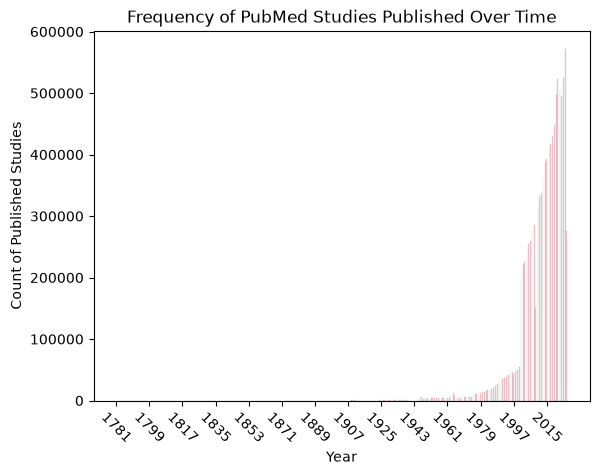

In [65]:
sns.histplot(data = pm_df, x='year', binwidth=0.4, color='pink')
plt.xticks(np.arange(1781, 2027, step = 18), rotation = -45)
plt.xlabel("Year")
plt.ylabel("Count of Published Studies")
plt.title("Frequency of PubMed Studies Published Over Time")
plt.show()

# cleaned_raw_pubmed_data.csv into LAZYFRAME

In [2]:
raw_df = pl.scan_csv("/Users/shantibrodnick/Downloads/510Capstone/GenderDisparityinResearch/notebooks/Article_Data_APIs/data/cleaned_raw_pubmed_data.csv")

In [19]:
raw_df.select(pl.len()).collect().item()
# 10,206,788 rows

10206788

In [20]:
raw_df.head(2).collect()

title,abstract,journal,date,authors,doi
str,str,str,str,str,str
"""Anti-tumor necrosis factor-alp…","""The aim of this study was to a…","""Rheumatology international""","""2006-10-20""","""['YasunoriKageyama', 'EijiTori…","""10.1007/s00296-006-0241-1"""
"""[Quantification of expression …","""To investigate quantification …","""Beijing da xue xue bao. Yi xue…","""2006-10-28""","""['Zhan-kunChen', 'Hou-shanLv']""",null


## Date Cleaning for that one column

In [ ]:
# Find all the length of all unique dates
raw_df.select(pl.col('date').cast(pl.String).str.len_chars()).unique().collect()
# 4, 10, and 98
# 98 is odd

In [ ]:
# The 98 was the formatting issue which is taken care of in the pubmed_final_data_export.ipynb
raw_df.filter(pl.col('date').cast(pl.String).str.len_chars() == 98).collect()

title,abstract,journal,date,authors,doi
str,str,str,str,str,str
"""Comparing Essure® and Tubal Li…","""Hundreds of thousands of US wo…","""2021""","""['Aileen M.Gariepy', 'Daniel J…","""10.25302/10.2021.CER.160936359""",null


In [ ]:
# Define row that is all shifted over
row = pl.col('date').cast(pl.String).str.len_chars() == 98

In [ ]:
# Replace like we did in pubmed_final_data_export
f_raw_df = raw_df.with_columns([
    pl.when(row).then(pl.col('date')).otherwise(pl.col('authors')).alias('authors'),
    pl.when(row).then(pl.col('journal')).otherwise(pl.col('date')).alias('date'),
    pl.when(row).then(None).otherwise(pl.col('journal')).alias('journal')
])

In [ ]:
# Check to see if the row changed
f_raw_df.filter(pl.col('doi') == "10.25302/10.2021.CER.160936359").collect()
# YAY IT DID

title,abstract,journal,date,authors,doi
str,str,str,str,str,str
"""Comparing Essure® and Tubal Li…","""Hundreds of thousands of US wo…",null,"""2021""","""['Aileen M.Gariepy', 'Daniel J…","""10.25302/10.2021.CER.160936359"""


In [ ]:
# Find the row with 4
raw_df.filter(pl.col('date').cast(pl.String).str.len_chars() == 4).collect()

title,abstract,journal,date,authors,doi
str,str,str,str,str,str
"""Molecular Imaging and Contrast…","""The Molecular Imaging and Cont…",null,"""2004""","""[]""",null
"""Screening for Hereditary Hemoc…","""To assess evidence sufficiency…",null,"""2006""","""['Evelyn PWhitlock', 'Betsy AG…",null
"""WHO Guideline on Syphilis Scre…","""Since the publication of the W…",null,"""2017""","""[]""",null
"""Using nationwide ‘big data’ fr…","""Electronic health records (EHR…",null,"""2017""","""['HarryHemingway', 'Gene SFede…","""10.3310/pgfar05040"""
"""Can Coping-Skills Training Hel…","""Many survivors of critical ill…",null,"""2018""","""['Christopher E.Cox', 'Catheri…","""10.25302/9.2018.CER.195"""
…,…,…,…,…,…
"""Recommendations for Drug Thera…","""Evidence-informed recommendati…",null,"""2013""","""[]""",null
"""Evidence review for previous c…","""The aim of this review is to d…",null,"""2019""","""['NoneNone']""",null
"""WHO consolidated guidelines fo…","""Respiratory illness remains a …",null,"""2026""","""[]""",null


In [ ]:
# Standardize the date column to make sure it has 10
ff_raw_df = f_raw_df.with_columns(
    pl.when(pl.col('date').cast(pl.String).str.len_chars() == 4).then(pl.col('date').cast(pl.String) + "-01-01")
    .otherwise(pl.col('date').cast(pl.String))
)

In [ ]:
# Check to see if it worked
ff_raw_df.select(pl.col('date').cast(pl.String).str.len_chars()).unique().collect()
# Yay it worked!

date
u32
10


In [43]:
ff_raw_df.select(pl.col('date').max()).collect()

date
str
"""2026-07-01"""


In [55]:
ff_raw_df.select(pl.col('date').min()).collect()

date
str
"""1781-06-01"""


### Change date to datetime

In [44]:
# Change rows to datetime
dt_raw_df = ff_raw_df.with_columns(
    pl.col('date').str.strptime(pl.Date, format = "%Y-%m-%d")
    )

In [15]:
#pl.Config.restore_defaults()
dt_raw_df.head(2).collect()

NameError: name 'dt_raw_df' is not defined

### Drop authors column

In [58]:
dt_drop_raw_df = dt_raw_df.drop(['authors'])

## Now I want to filter for only years between 1948 - 2026

In [26]:
# Filter between 1948 - 2026
fil_raw_df = dt_raw_df.filter(pl.col('date').is_between(date(1948, 1, 1), date(2026, 6, 30)))

In [ ]:
# Check row count now
fil_raw_df.select(pl.len()).collect().item()
# 10,185,407
# Too big

10185407

In [ ]:
#raw_df_00_26.select(pl.len()).collect().item()
# 9,380,169
# #raw_df_00_26.collect().estimated_size("mb")
# 14 GB

9380169

In [55]:
#pl.Config(fmt_str_lengths=2000, tbl_rows=2)
fil_raw_df.head(2).collect()

title,abstract,journal,date,authors,doi
str,str,str,date,str,str
"""Anti-tumor necrosis factor-alp…","""The aim of this study was to a…","""Rheumatology international""",2006-10-20,"""['YasunoriKageyama', 'EijiTori…","""10.1007/s00296-006-0241-1"""
"""[Quantification of expression …","""To investigate quantification …","""Beijing da xue xue bao. Yi xue…",2006-10-28,"""['Zhan-kunChen', 'Hou-shanLv']""",null


### Save cleaned lazyframe as a csv

In [60]:
dt_drop_raw_df.sink_csv('pubmed_cleaned_drop_author.csv')